In [1]:
import os
import sys
import json
import logging
import argparse
import torch

print("MPS available:", torch.backends.mps.is_available())
print("CUDA version:", torch.version.cuda)

# Show MPS device info safely
if torch.backends.mps.is_available():
    print("MPS backend is active on macOS (Metal).")
    print("Device: Apple GPU via Metal Performance Shaders (MPS).")
else:
    print("MPS not available — running on CPU instead.")

print("CPU cores:", os.cpu_count())


MPS available: True
CUDA version: None
MPS backend is active on macOS (Metal).
Device: Apple GPU via Metal Performance Shaders (MPS).
CPU cores: 16


In [2]:
import ipywidgets as widgets
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import wot

%cd /Users/user/Downloads/

[Errno 2] No such file or directory: '/Users/user/Downloads/'
/Users/alireza/Desktop/Paper_Code


In [3]:
# Path to input files
FLE_COORDS_PATH ='serum_2i/fle_coords.txt'
FULL_DS_PATH = 'serum_2i/ExprMatrix.h5ad'
VAR_DS_PATH = 'serum_2i/ExprMatrix.var.genes.h5ad'
CELL_DAYS_PATH = 'serum_2i/cell_days.txt'
GENE_SETS_PATH = 'serum_2i/gene_sets.gmx'
GENE_SET_SCORES_PATH = 'serum_2i/gene_set_scores.csv'
CELL_SETS_PATH = 'serum_2i/cell_sets.gmt'

coord_df = pd.read_csv(FLE_COORDS_PATH, index_col='id', sep='\t')
days_df = pd.read_csv(CELL_DAYS_PATH, index_col='id', sep='\t')

# Read expression matrix, cell days, and 2-d coordinates
adata_big = wot.io.read_dataset(FULL_DS_PATH, obs=[days_df,coord_df])
adata = wot.io.read_dataset(VAR_DS_PATH, obs=[days_df,coord_df])
unique_days = adata.obs['day'].unique()

In [ ]:
import scanpy as sc

# If adata is already normalized/log1p etc., you can still run HVGs, but results depend on preprocessing.
sc.pp.highly_variable_genes(adata_big, n_top_genes=50, flavor="seurat_v3")  
adata_50 = adata_big[:, adata_big.var["highly_variable"]].copy()

print(adata_50.shape)  # (251203, 50)

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


(251203, 50)


In [18]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional, Union
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()
torch.mps.synchronize()


def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}


    out['mmd2_gamma_0.050'] = mmd_distance(y_true, y_pred, gamma=0.05)
    out['mmd2_gamma_0.075'] = mmd_distance(y_true, y_pred, gamma=0.075)
    out['mmd2_gamma_0.100'] = mmd_distance(y_true, y_pred, gamma=0.1)
    out['mmd2_gamma_0.250'] = mmd_distance(y_true, y_pred, gamma=0.2)
    out['mmd2_gamma_0.500'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.000'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance_sinkhorn'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="sinkhorn", reg=5e-2)
    out['wasserstein_distance_emd'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")

    return out

def split_train_test(
    X: np.ndarray,
    Y: np.ndarray,
    test_size: Union[int, float],
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Random train/test split.

    - If test_size is an int: use that many samples as test data.
    - If test_size is a float in (0, 1): use that fraction of the data as test data.
    """

    # Ensure X and Y have the same length
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    if n < 2:
        raise ValueError("Need at least 2 samples to create train and test splits.")

    # Determine number of test samples
    if isinstance(test_size, float):
        if not (0.0 < test_size < 1.0):
            raise ValueError("When float, test_size must be in (0, 1).")
        n_test = max(1, int(round(n * test_size)))
    else:  # assume integer-like
        n_test = int(test_size)
        if n_test <= 0:
            raise ValueError("When int, test_size must be positive.")
    
    # Ensure at least 1 train sample remains
    if n_test >= n:
        n_test = n - 1

    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    te_idx, tr_idx = idx[:n_test], idx[n_test:]

    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]


In [ ]:

def LAOT(
    X_tr_pre, Y_tr_post, X_te_pre, Y_te_post,
    n_epochs=3000, batch_size=2048, lr=1e-3, device="auto", seed=12345, verbose=True
):
    import torch, numpy as np, random, ot
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.preprocessing import StandardScaler

    # ---------------- Device check ---------------- #
    if device == "auto":
        device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    
    # Helper: only pin memory for CPU→CUDA pipeline
    def should_pin(device, tensor):
        return (device.startswith("mps") and tensor.device.type == "cpu")

    # ---------------- Helper Functions ---------------- #
    def cost_matrix(X, Y):
        X2 = (X**2).sum(1, keepdims=True)
        Y2 = (Y**2).sum(1, keepdims=True).T
        return X2 + Y2 - 2 * X @ Y.T

    def exact_ot_plan(X, Y):
        a, b = torch.ones(len(X)), torch.ones(len(Y))
        C = cost_matrix(X, Y)
        Pi = ot.emd(a, b, C, numItermax=int(1e7))
        return Pi, C

    class Mapper(nn.Module):
        def __init__(self, d):
            super().__init__()
            self.first = nn.Linear(d, d, bias=False)
            nn.init.eye_(self.first.weight)
        def forward(self, x):
            return self.first(x)
        def loss(self, Xmap, Y, P):
            return torch.norm(Y - P.T @ Xmap)**2

    # ---------------- Data Setup ---------------- #
    scaler = StandardScaler()

    XY = np.vstack([X_tr_pre, Y_tr_post])
    XYs = torch.tensor(scaler.fit_transform(XY), dtype=torch.float32, device=device)

    n = len(X_tr_pre)
    Xtr_s = XYs[:n]
    Ytr_s = XYs[n:]

    Xte_s = torch.tensor(scaler.transform(X_te_pre), dtype=torch.float32, device=device)
    Yte = torch.tensor(Y_te_post, dtype=torch.float32, device=device)

    # Build dataloader (pin only if CPU→CUDA)
    pin = should_pin(device, Xtr_s)
    train_loader = DataLoader(
        TensorDataset(Xtr_s, Ytr_s),
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin
    )

    # ---------------- Seed ---------------- #
    torch.manual_seed(seed); random.seed(seed); np.random.seed(seed)

    mapper = Mapper(X_tr_pre.shape[1]).to(device)
    opt = torch.optim.Adam(mapper.parameters(), lr=lr, weight_decay=1e-4)

    # ---------------- Training Loop ---------------- #
    for epoch in range(n_epochs+1):
        mapper.train()
        for bx, by in train_loader:

            Xmap = mapper(bx)
            with torch.no_grad():
                P,_ = exact_ot_plan(Xmap, by)
                if isinstance(P, np.ndarray):
                    P = torch.from_numpy(P).to(device=device, dtype=torch.float32)
                else:
                    P = P.clone().detach().to(device=device, dtype=torch.float32)
                    
            opt.zero_grad(set_to_none=True)
            loss = mapper.loss(Xmap, by, P)
            loss.backward()
            opt.step()

        # Logging
        if verbose and epoch % 100 == 0:
            mapper.eval()
            with torch.no_grad():
                train_map = mapper(Xtr_s)
                train_map_unscaled = scaler.inverse_transform(train_map.cpu().numpy())
                Y_train_unscaled = scaler.inverse_transform(Ytr_s.cpu().numpy())
                train_mmd = mmd_distance(train_map_unscaled, Y_train_unscaled, 0.1)

                te_s = mapper(Xte_s)
                te = scaler.inverse_transform(te_s.cpu())
                test_mmd = mmd_distance(te, Yte.cpu().numpy(), 0.1)

            print(f"Epoch {epoch} | Train Loss {loss.item():.4f} | Train MMD {train_mmd:.4f} | Test MMD {test_mmd:.4f} ")


    # ---------------- Final Eval ---------------- #
    mapper.eval()
    with torch.no_grad():
        te_s = mapper(Xte_s)
        te = scaler.inverse_transform(te_s.cpu().numpy())
        test_mmd = mmd_distance(te, Yte.cpu().numpy(), 0.1)
        test_wasserstein = wasserstein_pointcloud(te, Yte.cpu().numpy(), p=2, method="emd")

    # Get the matrix called "first"
    first_matrix = mapper.first.weight.detach().cpu().numpy()

    return {
        "test_map": te,
        "test_mmd": test_mmd,
        "test_wasserstein": test_wasserstein,
        "model": mapper,
        "scaler": scaler,
        "device": device,
        "first_matrix": first_matrix,
    }

In [ ]:
# Subset AnnData to cells from that first day

mask_pre = (adata_big.obs["day"] == 8.5) & adata_big.obs_names.str.contains("2i")
mask_post = (adata_big.obs["day"] == 9.0) & adata_big.obs_names.str.contains("2i")


X_pre = adata_50[mask_pre].copy().to_df()
X_post = adata_50[mask_post].copy().to_df()


X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 500)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# ---------------- Run multiple times ---------------- #

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=2000, batch_size=4096, lr=1e-5, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, 0.01)
    all_metrics.append(metrics)

    # Identity with the same shape as upper_half
    I = np.eye(out['first_matrix'].shape[0], out['first_matrix'].shape[1])
    diff = out['first_matrix'] - I
    fro_norm = np.linalg.norm(diff, "fro")
    print("Frobenius norm ||W - I||_F =", fro_norm)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

(1534, 50)
(500, 50)
(1534, 50)
(500, 50)
**************** Run: 0 ****************
Epoch 0 | Train Loss 42082.3672 | Train MMD 0.0178 | Test MMD 0.0172 
Epoch 100 | Train Loss 41887.5625 | Train MMD 0.0175 | Test MMD 0.0169 
Epoch 200 | Train Loss 41701.6523 | Train MMD 0.0172 | Test MMD 0.0166 
Epoch 300 | Train Loss 41523.3789 | Train MMD 0.0170 | Test MMD 0.0164 
Epoch 400 | Train Loss 41353.2930 | Train MMD 0.0168 | Test MMD 0.0162 
Epoch 500 | Train Loss 41190.4141 | Train MMD 0.0166 | Test MMD 0.0160 
Epoch 600 | Train Loss 41033.8750 | Train MMD 0.0164 | Test MMD 0.0158 
Epoch 700 | Train Loss 40882.8594 | Train MMD 0.0163 | Test MMD 0.0157 
Epoch 800 | Train Loss 40736.5469 | Train MMD 0.0161 | Test MMD 0.0155 
Epoch 900 | Train Loss 40595.2344 | Train MMD 0.0160 | Test MMD 0.0154 
Epoch 1000 | Train Loss 40459.3086 | Train MMD 0.0159 | Test MMD 0.0153 
Epoch 1100 | Train Loss 40324.2461 | Train MMD 0.0158 | Test MMD 0.0151 
Epoch 1200 | Train Loss 40194.3711 | Train MMD 0.0157

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


In [ ]:
# Subset AnnData to cells from that first day

mask_pre = (adata_big.obs["day"] == 8.5) & adata_big.obs_names.str.contains("2i")
mask_post = (adata_big.obs["day"] == 9.5) & adata_big.obs_names.str.contains("2i")


X_pre = adata_50[mask_pre].copy().to_df()
X_post = adata_50[mask_post].copy().to_df()


X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 500)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# ---------------- Run multiple times ---------------- #

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=2000, batch_size=4096, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, 0.01)
    all_metrics.append(metrics)

    # Identity with the same shape as upper_half
    I = np.eye(out['first_matrix'].shape[0], out['first_matrix'].shape[1])
    diff = out['first_matrix'] - I
    fro_norm = np.linalg.norm(diff, "fro")
    print("Frobenius norm ||W - I||_F =", fro_norm)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

(1083, 50)
(500, 50)
(1083, 50)
(500, 50)
**************** Run: 0 ****************
Epoch 0 | Train Loss 52056.8164 | Train MMD 0.0711 | Test MMD 0.0569 
Epoch 100 | Train Loss 49759.6094 | Train MMD 0.0716 | Test MMD 0.0571 
Epoch 200 | Train Loss 47876.5898 | Train MMD 0.0715 | Test MMD 0.0567 
Epoch 300 | Train Loss 46244.0117 | Train MMD 0.0705 | Test MMD 0.0556 
Epoch 400 | Train Loss 44783.4766 | Train MMD 0.0693 | Test MMD 0.0543 
Epoch 500 | Train Loss 43459.5586 | Train MMD 0.0677 | Test MMD 0.0528 
Epoch 600 | Train Loss 42273.8477 | Train MMD 0.0658 | Test MMD 0.0510 
Epoch 700 | Train Loss 41211.9883 | Train MMD 0.0638 | Test MMD 0.0490 
Epoch 800 | Train Loss 40242.5664 | Train MMD 0.0617 | Test MMD 0.0471 
Epoch 900 | Train Loss 39367.6406 | Train MMD 0.0597 | Test MMD 0.0451 
Epoch 1000 | Train Loss 38570.7656 | Train MMD 0.0578 | Test MMD 0.0433 
Epoch 1100 | Train Loss 37848.5000 | Train MMD 0.0557 | Test MMD 0.0413 
Epoch 1200 | Train Loss 37206.1836 | Train MMD 0.0539

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


In [ ]:
# Subset AnnData to cells from that first day

mask_pre = (adata_big.obs["day"] == 8.5) & adata_big.obs_names.str.contains("2i")
mask_post = (adata_big.obs["day"] == 10.0) & adata_big.obs_names.str.contains("2i")


X_pre = adata_50[mask_pre].copy().to_df()
X_post = adata_50[mask_post].copy().to_df()


X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 500)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# ---------------- Run multiple times ---------------- #

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=2000, batch_size=4096, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, 0.01)
    all_metrics.append(metrics)

    # Identity with the same shape as upper_half
    I = np.eye(out['first_matrix'].shape[0], out['first_matrix'].shape[1])
    diff = out['first_matrix'] - I
    fro_norm = np.linalg.norm(diff, "fro")
    print("Frobenius norm ||W - I||_F =", fro_norm)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

(1380, 50)
(500, 50)
(1380, 50)
(500, 50)
**************** Run: 0 ****************
Epoch 0 | Train Loss 69517.2969 | Train MMD 0.0834 | Test MMD 0.0781 
Epoch 100 | Train Loss 66067.2422 | Train MMD 0.0855 | Test MMD 0.0801 
Epoch 200 | Train Loss 63225.8516 | Train MMD 0.0866 | Test MMD 0.0810 
Epoch 300 | Train Loss 60788.9414 | Train MMD 0.0866 | Test MMD 0.0809 
Epoch 400 | Train Loss 58630.4297 | Train MMD 0.0858 | Test MMD 0.0800 
Epoch 500 | Train Loss 56725.9453 | Train MMD 0.0843 | Test MMD 0.0784 
Epoch 600 | Train Loss 55037.1719 | Train MMD 0.0821 | Test MMD 0.0762 
Epoch 700 | Train Loss 53521.3281 | Train MMD 0.0796 | Test MMD 0.0738 
Epoch 800 | Train Loss 52169.8203 | Train MMD 0.0771 | Test MMD 0.0713 
Epoch 900 | Train Loss 50962.3984 | Train MMD 0.0745 | Test MMD 0.0688 
Epoch 1000 | Train Loss 49851.6289 | Train MMD 0.0718 | Test MMD 0.0662 
Epoch 1100 | Train Loss 48839.8750 | Train MMD 0.0687 | Test MMD 0.0633 
Epoch 1200 | Train Loss 47909.8867 | Train MMD 0.0657

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: overflow encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


In [ ]:
# Subset AnnData to cells from that first day

mask_pre = (adata_big.obs["day"] == 8.5) & adata_big.obs_names.str.contains("2i")
mask_post = (adata_big.obs["day"] == 10.5) & adata_big.obs_names.str.contains("2i")


X_pre = adata_50[mask_pre].copy().to_df()
X_post = adata_50[mask_post].copy().to_df()


X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 500)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# ---------------- Run multiple times ---------------- #

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=2000, batch_size=4096, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, 0.01)
    all_metrics.append(metrics)

    # Identity with the same shape as upper_half
    I = np.eye(out['first_matrix'].shape[0], out['first_matrix'].shape[1])
    diff = out['first_matrix'] - I
    fro_norm = np.linalg.norm(diff, "fro")
    print("Frobenius norm ||W - I||_F =", fro_norm)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

(955, 50)
(500, 50)
(955, 50)
(500, 50)
**************** Run: 0 ****************
Epoch 0 | Train Loss 48610.9492 | Train MMD 0.1069 | Test MMD 0.0940 
Epoch 100 | Train Loss 45675.3125 | Train MMD 0.1068 | Test MMD 0.0937 
Epoch 200 | Train Loss 43249.8125 | Train MMD 0.1059 | Test MMD 0.0929 
Epoch 300 | Train Loss 41210.6797 | Train MMD 0.1044 | Test MMD 0.0915 
Epoch 400 | Train Loss 39464.7891 | Train MMD 0.1023 | Test MMD 0.0898 
Epoch 500 | Train Loss 37928.0039 | Train MMD 0.0997 | Test MMD 0.0875 
Epoch 600 | Train Loss 36568.1758 | Train MMD 0.0967 | Test MMD 0.0850 
Epoch 700 | Train Loss 35397.5000 | Train MMD 0.0934 | Test MMD 0.0821 
Epoch 800 | Train Loss 34361.8281 | Train MMD 0.0897 | Test MMD 0.0790 
Epoch 900 | Train Loss 33436.4922 | Train MMD 0.0857 | Test MMD 0.0755 
Epoch 1000 | Train Loss 32617.9785 | Train MMD 0.0819 | Test MMD 0.0724 
Epoch 1100 | Train Loss 31884.3164 | Train MMD 0.0780 | Test MMD 0.0690 
Epoch 1200 | Train Loss 31244.6953 | Train MMD 0.0742 |

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


In [ ]:
# Subset AnnData to cells from that first day

mask_pre = (adata_big.obs["day"] == 8.5) & adata_big.obs_names.str.contains("2i")
mask_post = (adata_big.obs["day"] == 11.5) & adata_big.obs_names.str.contains("2i")


X_pre = adata_50[mask_pre].copy().to_df()
X_post = adata_50[mask_post].copy().to_df()


X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 500)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# ---------------- Run multiple times ---------------- #

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=2000, batch_size=4096, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, 0.01)
    all_metrics.append(metrics)

    # Identity with the same shape as upper_half
    I = np.eye(out['first_matrix'].shape[0], out['first_matrix'].shape[1])
    diff = out['first_matrix'] - I
    fro_norm = np.linalg.norm(diff, "fro")
    print("Frobenius norm ||W - I||_F =", fro_norm)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

(879, 50)
(500, 50)
(879, 50)
(500, 50)
**************** Run: 0 ****************
Epoch 0 | Train Loss 51230.8398 | Train MMD 0.1214 | Test MMD 0.1124 
Epoch 100 | Train Loss 47904.9375 | Train MMD 0.1190 | Test MMD 0.1099 
Epoch 200 | Train Loss 45104.3555 | Train MMD 0.1156 | Test MMD 0.1066 
Epoch 300 | Train Loss 42729.5430 | Train MMD 0.1118 | Test MMD 0.1029 
Epoch 400 | Train Loss 40694.5625 | Train MMD 0.1078 | Test MMD 0.0991 
Epoch 500 | Train Loss 38939.0352 | Train MMD 0.1035 | Test MMD 0.0953 
Epoch 600 | Train Loss 37415.2422 | Train MMD 0.0993 | Test MMD 0.0914 
Epoch 700 | Train Loss 36090.8594 | Train MMD 0.0951 | Test MMD 0.0877 
Epoch 800 | Train Loss 34980.4609 | Train MMD 0.0911 | Test MMD 0.0841 
Epoch 900 | Train Loss 34028.3672 | Train MMD 0.0872 | Test MMD 0.0807 
Epoch 1000 | Train Loss 33193.5820 | Train MMD 0.0833 | Test MMD 0.0773 
Epoch 1100 | Train Loss 32480.7285 | Train MMD 0.0797 | Test MMD 0.0741 
Epoch 1200 | Train Loss 31868.4453 | Train MMD 0.0763 |

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: overflow encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


In [ ]:
# Subset AnnData to cells from that first day

mask_pre = (adata_big.obs["day"] == 8.5) & adata_big.obs_names.str.contains("2i")
mask_post = (adata_big.obs["day"] == 12.5) & adata_big.obs_names.str.contains("2i")


X_pre = adata_50[mask_pre].copy().to_df()
X_post = adata_50[mask_post].copy().to_df()


X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 500)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# ---------------- Run multiple times ---------------- #

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=2000, batch_size=4096, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, 0.01)
    all_metrics.append(metrics)

    # Identity with the same shape as upper_half
    I = np.eye(out['first_matrix'].shape[0], out['first_matrix'].shape[1])
    diff = out['first_matrix'] - I
    fro_norm = np.linalg.norm(diff, "fro")
    print("Frobenius norm ||W - I||_F =", fro_norm)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

(857, 50)
(500, 50)
(857, 50)
(500, 50)
**************** Run: 0 ****************
Epoch 0 | Train Loss 51864.4609 | Train MMD 0.1312 | Test MMD 0.1212 
Epoch 100 | Train Loss 48579.7109 | Train MMD 0.1274 | Test MMD 0.1178 
Epoch 200 | Train Loss 45829.3242 | Train MMD 0.1228 | Test MMD 0.1137 
Epoch 300 | Train Loss 43514.6328 | Train MMD 0.1179 | Test MMD 0.1093 
Epoch 400 | Train Loss 41541.8945 | Train MMD 0.1128 | Test MMD 0.1046 
Epoch 500 | Train Loss 39849.8750 | Train MMD 0.1075 | Test MMD 0.0997 
Epoch 600 | Train Loss 38402.6094 | Train MMD 0.1023 | Test MMD 0.0950 
Epoch 700 | Train Loss 37152.9844 | Train MMD 0.0972 | Test MMD 0.0905 
Epoch 800 | Train Loss 36077.0586 | Train MMD 0.0925 | Test MMD 0.0862 
Epoch 900 | Train Loss 35151.3359 | Train MMD 0.0881 | Test MMD 0.0822 
Epoch 1000 | Train Loss 34346.2852 | Train MMD 0.0840 | Test MMD 0.0785 
Epoch 1100 | Train Loss 33654.3398 | Train MMD 0.0802 | Test MMD 0.0752 
Epoch 1200 | Train Loss 33051.0234 | Train MMD 0.0768 |

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


In [ ]:
# Subset AnnData to cells from that first day

mask_pre = (adata_big.obs["day"] == 8.5) & adata_big.obs_names.str.contains("2i")
mask_post = (adata_big.obs["day"] == 13.5) & adata_big.obs_names.str.contains("2i")


X_pre = adata_50[mask_pre].copy().to_df()
X_post = adata_50[mask_post].copy().to_df()


X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 500)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# ---------------- Run multiple times ---------------- #

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=2000, batch_size=4096, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, 0.01)
    all_metrics.append(metrics)

    # Identity with the same shape as upper_half
    I = np.eye(out['first_matrix'].shape[0], out['first_matrix'].shape[1])
    diff = out['first_matrix'] - I
    fro_norm = np.linalg.norm(diff, "fro")
    print("Frobenius norm ||W - I||_F =", fro_norm)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

(1103, 50)
(500, 50)
(1103, 50)
(500, 50)
**************** Run: 0 ****************
Epoch 0 | Train Loss 62053.0117 | Train MMD 0.1346 | Test MMD 0.1318 
Epoch 100 | Train Loss 57746.9453 | Train MMD 0.1298 | Test MMD 0.1272 
Epoch 200 | Train Loss 54151.3477 | Train MMD 0.1239 | Test MMD 0.1216 
Epoch 300 | Train Loss 51095.0625 | Train MMD 0.1172 | Test MMD 0.1152 
Epoch 400 | Train Loss 48510.9375 | Train MMD 0.1102 | Test MMD 0.1085 
Epoch 500 | Train Loss 46331.4883 | Train MMD 0.1031 | Test MMD 0.1017 
Epoch 600 | Train Loss 44488.2969 | Train MMD 0.0961 | Test MMD 0.0950 
Epoch 700 | Train Loss 42937.5000 | Train MMD 0.0894 | Test MMD 0.0885 
Epoch 800 | Train Loss 41618.1836 | Train MMD 0.0831 | Test MMD 0.0824 
Epoch 900 | Train Loss 40468.8320 | Train MMD 0.0772 | Test MMD 0.0767 
Epoch 1000 | Train Loss 39467.9219 | Train MMD 0.0720 | Test MMD 0.0717 
Epoch 1100 | Train Loss 38622.8008 | Train MMD 0.0676 | Test MMD 0.0674 
Epoch 1200 | Train Loss 37901.1328 | Train MMD 0.0638

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: overflow encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


In [ ]:
# Subset AnnData to cells from that first day

mask_pre = (adata_big.obs["day"] == 8.5) & adata_big.obs_names.str.contains("2i")
mask_post = (adata_big.obs["day"] == 14.5) & adata_big.obs_names.str.contains("2i")


X_pre = adata_50[mask_pre].copy().to_df()
X_post = adata_50[mask_post].copy().to_df()


X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 500)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# ---------------- Run multiple times ---------------- #

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=2000, batch_size=4096, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, 0.01)
    all_metrics.append(metrics)

    # Identity with the same shape as upper_half
    I = np.eye(out['first_matrix'].shape[0], out['first_matrix'].shape[1])
    diff = out['first_matrix'] - I
    fro_norm = np.linalg.norm(diff, "fro")
    print("Frobenius norm ||W - I||_F =", fro_norm)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

(2327, 50)
(500, 50)
(2327, 50)
(500, 50)
**************** Run: 0 ****************
Epoch 0 | Train Loss 155197.6562 | Train MMD 0.2112 | Test MMD 0.2093 
Epoch 100 | Train Loss 145547.5156 | Train MMD 0.2062 | Test MMD 0.2047 
Epoch 200 | Train Loss 137686.0156 | Train MMD 0.1987 | Test MMD 0.1976 
Epoch 300 | Train Loss 131154.7031 | Train MMD 0.1891 | Test MMD 0.1885 
Epoch 400 | Train Loss 125681.1328 | Train MMD 0.1783 | Test MMD 0.1783 
Epoch 500 | Train Loss 121074.0547 | Train MMD 0.1667 | Test MMD 0.1672 
Epoch 600 | Train Loss 117101.8750 | Train MMD 0.1547 | Test MMD 0.1560 
Epoch 700 | Train Loss 113698.3359 | Train MMD 0.1426 | Test MMD 0.1446 
Epoch 800 | Train Loss 110766.7812 | Train MMD 0.1308 | Test MMD 0.1334 
Epoch 900 | Train Loss 108237.7266 | Train MMD 0.1195 | Test MMD 0.1227 
Epoch 1000 | Train Loss 106052.3750 | Train MMD 0.1089 | Test MMD 0.1126 
Epoch 1100 | Train Loss 104141.0703 | Train MMD 0.0993 | Test MMD 0.1035 
Epoch 1200 | Train Loss 102480.2500 | Tra

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: overflow encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


In [ ]:
# Subset AnnData to cells from that first day

mask_pre = (adata_big.obs["day"] == 8.5) & adata_big.obs_names.str.contains("2i")
mask_post = (adata_big.obs["day"] == 15.5) & adata_big.obs_names.str.contains("2i")


X_pre = adata_50[mask_pre].copy().to_df()
X_post = adata_50[mask_post].copy().to_df()


X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 500)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# ---------------- Run multiple times ---------------- #

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=2000, batch_size=4096, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, 0.01)
    all_metrics.append(metrics)

    # Identity with the same shape as upper_half
    I = np.eye(out['first_matrix'].shape[0], out['first_matrix'].shape[1])
    diff = out['first_matrix'] - I
    fro_norm = np.linalg.norm(diff, "fro")
    print("Frobenius norm ||W - I||_F =", fro_norm)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

(2327, 50)
(500, 50)
(2327, 50)
(500, 50)
**************** Run: 0 ****************
Epoch 0 | Train Loss 155492.1406 | Train MMD 0.2790 | Test MMD 0.2798 
Epoch 100 | Train Loss 144296.0938 | Train MMD 0.2789 | Test MMD 0.2798 
Epoch 200 | Train Loss 135156.0469 | Train MMD 0.2764 | Test MMD 0.2774 
Epoch 300 | Train Loss 127485.5078 | Train MMD 0.2712 | Test MMD 0.2719 
Epoch 400 | Train Loss 120941.5703 | Train MMD 0.2631 | Test MMD 0.2635 
Epoch 500 | Train Loss 115301.4141 | Train MMD 0.2523 | Test MMD 0.2522 
Epoch 600 | Train Loss 110437.8672 | Train MMD 0.2391 | Test MMD 0.2383 
Epoch 700 | Train Loss 106232.3125 | Train MMD 0.2238 | Test MMD 0.2222 
Epoch 800 | Train Loss 102599.9609 | Train MMD 0.2072 | Test MMD 0.2048 
Epoch 900 | Train Loss 99460.7578 | Train MMD 0.1902 | Test MMD 0.1871 
Epoch 1000 | Train Loss 96735.0859 | Train MMD 0.1732 | Test MMD 0.1694 
Epoch 1100 | Train Loss 94333.2500 | Train MMD 0.1567 | Test MMD 0.1524 
Epoch 1200 | Train Loss 92217.2578 | Train M

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


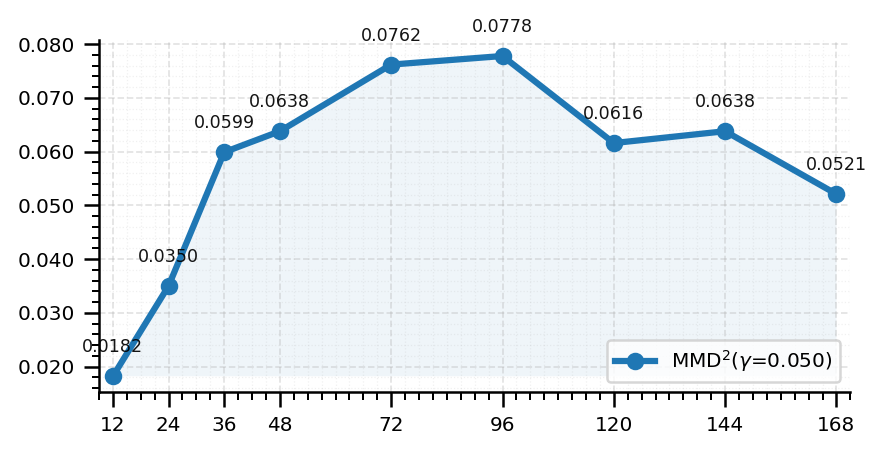

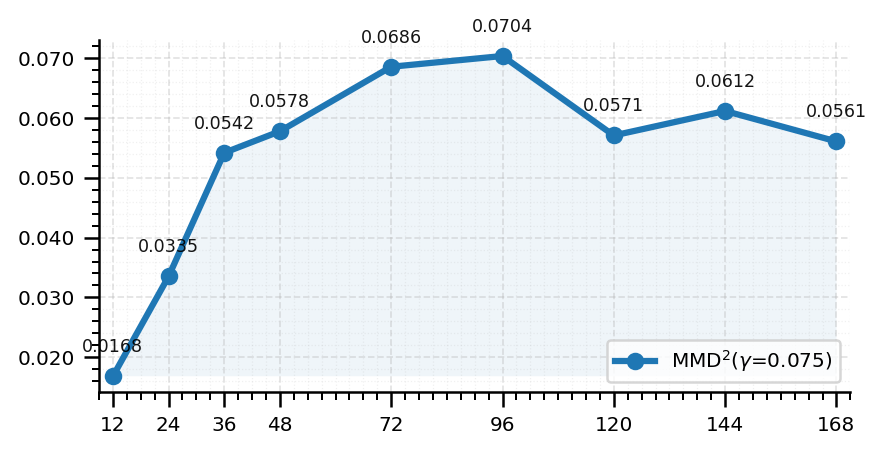

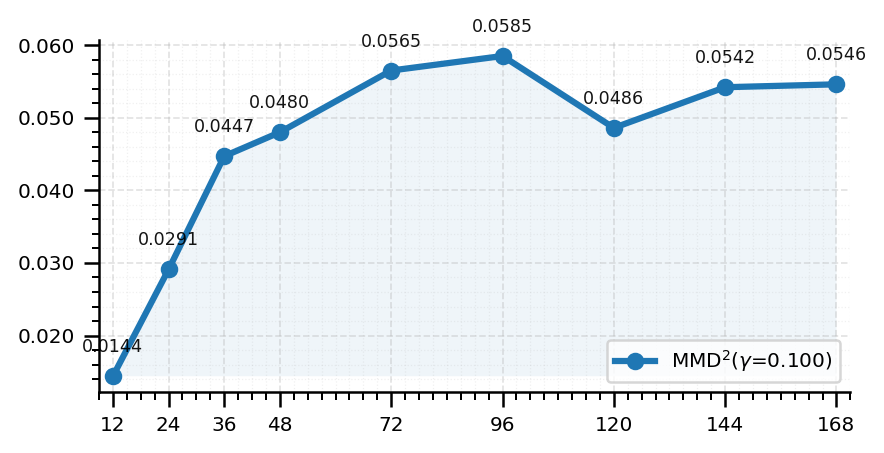

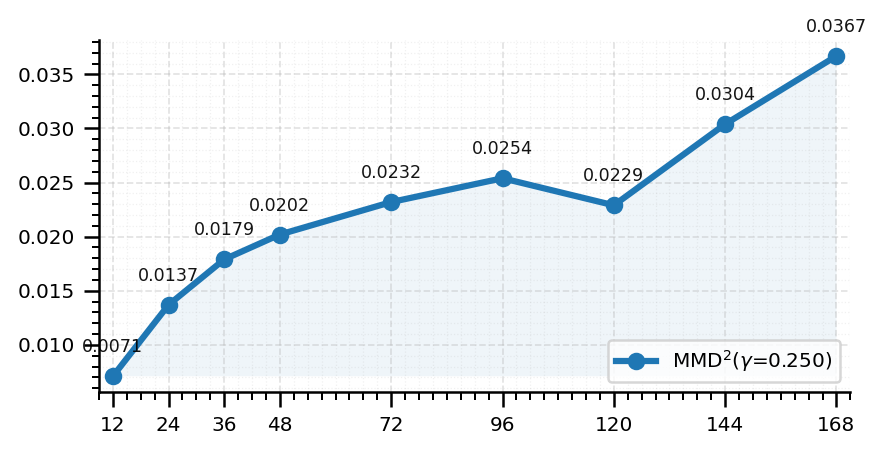

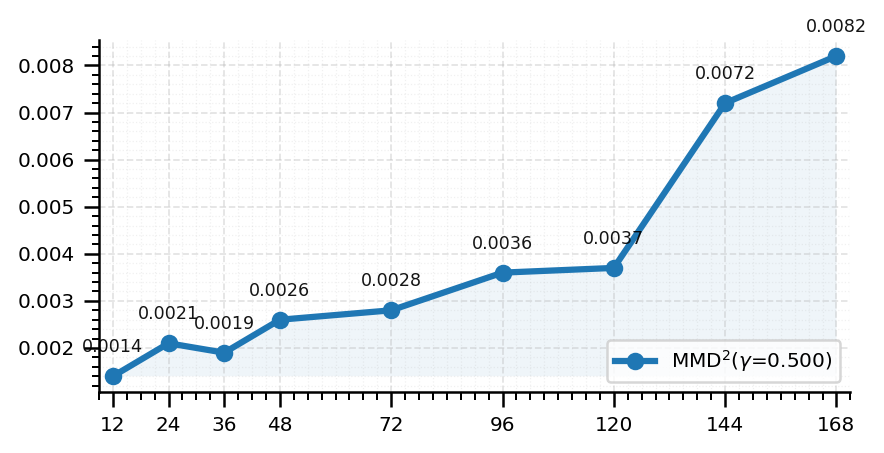

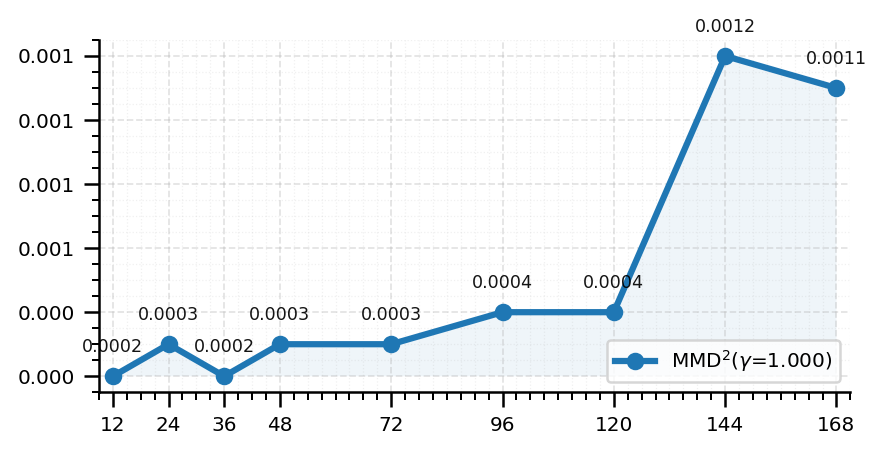

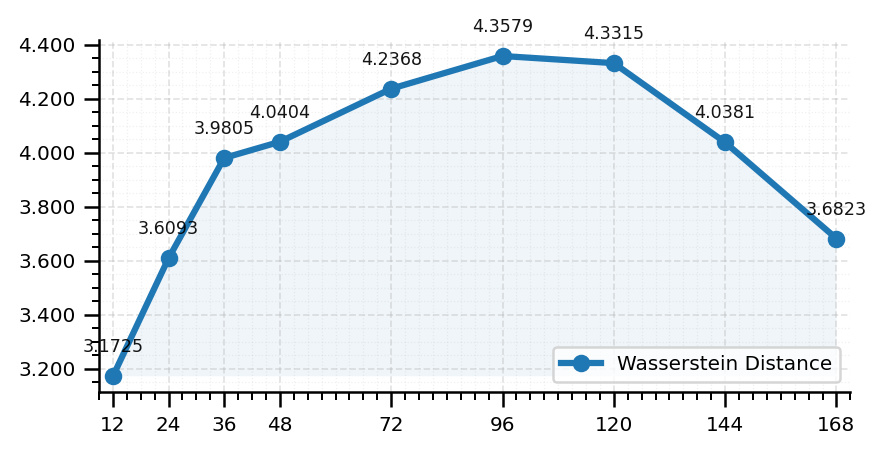

['mmd2_gamma_0.050_21.pdf',
 'mmd2_gamma_0.075_21.pdf',
 'mmd2_gamma_0.100_21.pdf',
 'mmd2_gamma_0.250_21.pdf',
 'mmd2_gamma_0.500_21.pdf',
 'mmd2_gamma_1.000_21.pdf',
 'wasserstein_distance_emd_21.pdf']

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

times = [12, 24, 36, 48, 72, 96, 120, 144, 168]

data = {
    "mmd2_gamma_0.050": [0.0182, 0.0350, 0.0599, 0.0638, 0.0762, 0.0778, 0.0616, 0.0638, 0.0521],
    "mmd2_gamma_0.075": [0.0168, 0.0335, 0.0542, 0.0578, 0.0686, 0.0704, 0.0571, 0.0612, 0.0561],
    "mmd2_gamma_0.100": [0.0144, 0.0291, 0.0447, 0.0480, 0.0565, 0.0585, 0.0486, 0.0542, 0.0546],
    "mmd2_gamma_0.250": [0.0071, 0.0137, 0.0179, 0.0202, 0.0232, 0.0254, 0.0229, 0.0304, 0.0367],
    "mmd2_gamma_0.500": [0.0014, 0.0021, 0.0019, 0.0026, 0.0028, 0.0036, 0.0037, 0.0072, 0.0082],
    "mmd2_gamma_1.000": [0.0002, 0.0003, 0.0002, 0.0003, 0.0003, 0.0004, 0.0004, 0.0012, 0.0011],
    "wasserstein_distance_emd": [3.1725, 3.6093, 3.9805, 4.0404, 4.2368, 4.3579, 4.3315, 4.0381, 3.6823],
}

df = pd.DataFrame(data, index=times)
df.index.name = "time_hours"

plt.rcParams.update({
    "figure.dpi": 180,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlepad": 8,
})

def beautify_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(axis="both", which="major", length=6, width=1.0)
    ax.tick_params(axis="both", which="minor", length=3, width=0.8)
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.18)
    ax.margins(x=0.02)

def annotate_points(ax, x, y, fmt="{:.4g}", offset=(0, 8)):
    for xi, yi in zip(x, y):
        ax.annotate(fmt.format(yi), (xi, yi),
                    textcoords="offset points", xytext=offset,
                    ha="center", va="bottom", fontsize=7, alpha=0.92)

def mark_minmax(ax, x, y):
    y = np.asarray(y)
    imin = int(np.argmin(y))
    imax = int(np.argmax(y))

    # ax.plot([x[imax]], [y[imax]], marker="X", markersize=10, linestyle="None")
    # ax.plot([x[imin]], [y[imin]], marker="*", markersize=12, linestyle="None", color="green")
    # ax.annotate("min", (x[imin], y[imin]), textcoords="offset points",
    #             xytext=(-12, -18), ha="right", va="top", fontsize=9)
    # ax.annotate("max", (x[imax], y[imax]), textcoords="offset points",
    #             xytext=(12, 10), ha="left", va="bottom", fontsize=9)

out_paths = []
for metric in df.columns:
    x = df.index.values
    y = df[metric].values.astype(float)

    fig, ax = plt.subplots(figsize=(9.6/2, 4.8/2), constrained_layout=True)
    ax.plot(x, y, marker="o", linewidth=2.5, markersize=6, label=f"MMD$^2 (\\gamma$={metric.split('_')[-1]})" if metric.startswith("mmd2_") else "Wasserstein Distance")
    ax.legend( fontsize=8, loc="lower right")

    # ax.set_xlabel("Time (hours)")
    # ax.set_ylabel(f"MMD$^2 (\\gamma$={metric.split('_')[-1]})" if metric.startswith("mmd2_") else "Wasserstein Distance")
    ax.set_xticks(times)
    ax.set_xlim(min(times) - 3, max(times) + 3)
    # ax.set_title(metric.replace("_", " "))

    beautify_axes(ax)

    # if metric.startswith("mmd2_"):
    #     ax.set_yscale("log")
    #     ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=6))
    #     ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12))
    #     ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    #     annotate_points(ax, x, y, fmt="{:.2e}")
    #     ax.fill_between(x, y, np.full_like(y, y.min()), alpha=0.07)
    #     mark_minmax(ax, x, y)

    if metric == "wasserstein_distance_sinkhorn":
        ax.set_ylim(-0.05, 1.05)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
        annotate_points(ax, x, y, fmt="{:.1f}")
        ax.fill_between(x, y, np.zeros_like(y), alpha=0.10)
        ax.annotate("all values are 0.0", (x[len(x)//2], 0.0),
                    textcoords="offset points", xytext=(0, 18),
                    ha="center", va="bottom", fontsize=8, alpha=0.9)

    else:
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
        annotate_points(ax, x, y, fmt="{:.4f}")
        ax.fill_between(x, y, np.full_like(y, y.min()), alpha=0.07)
        mark_minmax(ax, x, y)

    path = f"{metric}_21.pdf"
    fig.savefig(path, format="pdf", bbox_inches="tight")
    out_paths.append(path)

    plt.show()
    plt.close(fig)

out_paths
